# HotpotQA question map & metric autopsy

**Source:** `results/accuracy_results.csv` · n=12 questions × 9 methods · HotpotQA distractor (hard)

This notebook is the GitHub-renderable version of the metric autopsy canvas: **question ID → text**, why EM/F1 “fail”, and the dual scoreboard that resolves the GraphRAG inconsistency.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT / "src"))

from rag_benchmark.charts import METHOD_LABELS
from rag_benchmark.metric_autopsy import (
    enrich_accuracy,
    method_metric_profile,
    question_catalog,
    disagreement_stats,
    scenario_dual_leaderboard,
    write_autopsy_artifacts,
)

RESULTS = ROOT / "results"
paths = write_autopsy_artifacts(
    results_dir=RESULTS,
    qa_path=ROOT / "data" / "qa" / "hotpot_eval.json",
    type_key="hotpot_type",
    scenario_col="query_type",
)
acc = enrich_accuracy(pd.read_csv(RESULTS / "accuracy_results.csv"))
stats = disagreement_stats(acc)
display(Markdown(
    f"| Stat | Value |\n|------|-------|\n"
    f"| Judge ≥0.5 but EM=0 | **{stats['judge_ge_05_but_em_0']}/{stats['n_rows']}** |\n"
    f"| Contains gold, still not EM | **{stats['contains_but_not_em']}** |\n"
    f"| Top LLM-judge method | **{METHOD_LABELS.get(stats['top_judge_method'], stats['top_judge_method'])}** ({stats['top_judge_value']:.2f}) |\n"
    f"| Graph* EM rate | **{stats['graph_em_rate']:.2f}** |"
))


| Stat | Value |
|------|-------|
| Judge ≥0.5 but EM=0 | **42/108** |
| Contains gold, still not EM | **26** |
| Top LLM-judge method | **Hybrid (vec+graph local)** (0.57) |
| Graph* EM rate | **0.00** |

## Why EM/F1 look like they are “failing”

They are not broken — they score **string identity**. Graph/hybrid answers are often long prose (“Yes, both are American film directors…”) while gold is a short span (“yes”, “Animorphs”, “3,677 seated”). The LLM judge rewards factual overlap; EM/F1 punish extra words. Composite averages all four, so generative stacks look weaker than they feel.


## Question catalog (ID → text)

Yellow highlight: models often “know” the answer (judge) but almost never exact-match the gold span.


In [2]:
catalog = question_catalog(acc, ROOT / "data" / "qa" / "hotpot_eval.json", type_key="hotpot_type")
demo = catalog.copy()
demo["id_short"] = demo["question_id"].str.slice(0, 10) + "…"

def _hl(row):
    if row.em_rate == 0 and row.avg_judge is not None and row.avg_judge >= 0.2:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)

cols = ["label", "id_short", "type", "question", "gold", "em_rate", "avg_judge", "avg_f1", "contains_rate", "avg_generative"]
display(demo[cols].style.apply(_hl, axis=1).format({
    "em_rate": "{:.0%}", "avg_judge": "{:.2f}", "avg_f1": "{:.2f}",
    "contains_rate": "{:.0%}", "avg_generative": "{:.2f}",
}))


,label,id_short,type,question,gold,em_rate,avg_judge,avg_f1,contains_rate,avg_generative
0,Q1,5a8c759555…,bridge,What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?,Chief of Protocol,0%,0.32,0.00,0%,0.16
1,Q2,5a85ea0955…,bridge,"What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?",Animorphs,22%,0.29,0.23,44%,0.37
2,Q3,5a8e3ea955…,bridge,"The director of the romantic comedy ""Big Stone Gap"" is based in what New York city?","Greenwich Village, New York City",0%,0.30,0.37,56%,0.43
3,Q4,5abd945255…,bridge,2014 S/S is the debut album of a South Korean boy group that was formed by who?,YG Entertainment,22%,0.40,0.23,33%,0.37
4,Q5,5a85b2d955…,bridge,Who was known by his stage name Aladin and helped organizations improve their performance as a consultant?,Eenasul Fateh,33%,0.52,0.34,44%,0.48
5,Q6,5a87ab9055…,bridge,The arena where the Lewiston Maineiacs played their home games can seat how many people?,"3,677 seated",0%,0.22,0.03,0%,0.11
6,Q7,5a8b57f255…,comparison,Were Scott Derrickson and Ed Wood of the same nationality?,yes,22%,0.31,0.23,33%,0.32
7,Q8,5adbf0a255…,comparison,Are the Laleli Mosque and Esma Sultan Mansion located in the same neighborhood?,no,44%,0.53,0.00,78%,0.66
8,Q9,5a8db19d55…,comparison,Are Local H and For Against both from the United States?,yes,22%,0.56,0.23,44%,0.50
9,Q10,5ab56e3255…,comparison,Are Random House Tower and 888 7th Avenue both used for real estate?,no,11%,0.32,0.00,33%,0.33


## What each metric measures

| Family | Metrics | When to trust |
|--------|---------|---------------|
| **Strict lexical** | Exact match, Token F1 | Short-span extractive QA (Hotpot EM) |
| **Soft / semantic** | Contains (≥80 fuzzy), LLM judge | Generative GraphRAG UX |

**Caveat:** judge = same local 3B as generator — directional, not BenchmarkQED AutoE.


## Dual scoreboard — this is the cutting-edge fix

| Score | Formula | Use for |
|-------|---------|---------|
| **Generative** | mean(judge, contains) | Graph / hybrid prose quality |
| **Extractive** | mean(F1, EM) | Hotpot-style short answers |
| **Composite** | mean(all four) | Legacy mix — can flip rankings |

On Hotpot **multi-hop**, GraphRAG fast/basic **wins generative** even when composite crowns Frontier/vector.


In [3]:
dual = scenario_dual_leaderboard(acc, scenario_col="query_type")
# Friendly scenario labels
dual = dual.replace({"hybrid": "multi-hop / bridge", "local": "comparison / local"})
display(Markdown("### Winners by score family"))
display(dual)

flips = dual[dual.ranking_flips]
if len(flips):
    display(Markdown(
        "**Ranking flip:** generative winner ≠ composite winner on: "
        + ", ".join(flips.scenario.tolist())
        + " — graphs were not worse; EM/composite under-credited them."
    ))


### Winners by score family

,scenario,generative_winner,generative_score,extractive_winner,extractive_score,composite_winner,composite_score,ranking_flips
0,multi-hop / bridge,GraphRAG fast/basic,0.667,FrontierRAG (adaptive+CRAG),0.396,FrontierRAG (adaptive+CRAG),0.406,True
1,comparison / local,Vector + rerank,0.625,Semantic (vector),0.500,Vector + rerank,0.557,False


**Ranking flip:** generative winner ≠ composite winner on: multi-hop / bridge — graphs were not worse; EM/composite under-credited them.

## Metric profile by method


,label,llm_judge,contains,token_f1,exact_match,generative,extractive,composite
6,GraphRAG fast/basic,0.567,0.667,0.077,0.000,0.617,0.039,0.328
7,Vector + rerank,0.500,0.500,0.369,0.333,0.500,0.351,0.426
5,Hybrid (vec+graph local),0.567,0.417,0.248,0.167,0.492,0.208,0.350
8,Semantic (vector),0.417,0.500,0.312,0.417,0.458,0.365,0.411
0,Adaptive router,0.375,0.500,0.405,0.417,0.438,0.411,0.424
1,FrontierRAG (adaptive+CRAG),0.375,0.500,0.467,0.333,0.438,0.400,0.419
4,BM25+dense (RRF),0.375,0.417,0.217,0.167,0.396,0.192,0.294
2,GraphRAG local,0.328,0.250,0.012,0.000,0.289,0.006,0.147
3,GraphRAG global,0.183,0.250,0.010,0.000,0.217,0.005,0.111


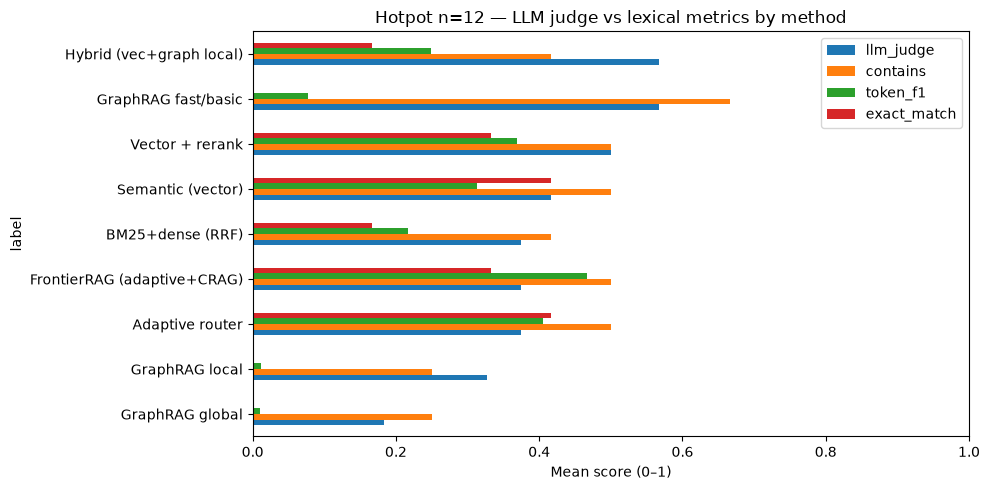

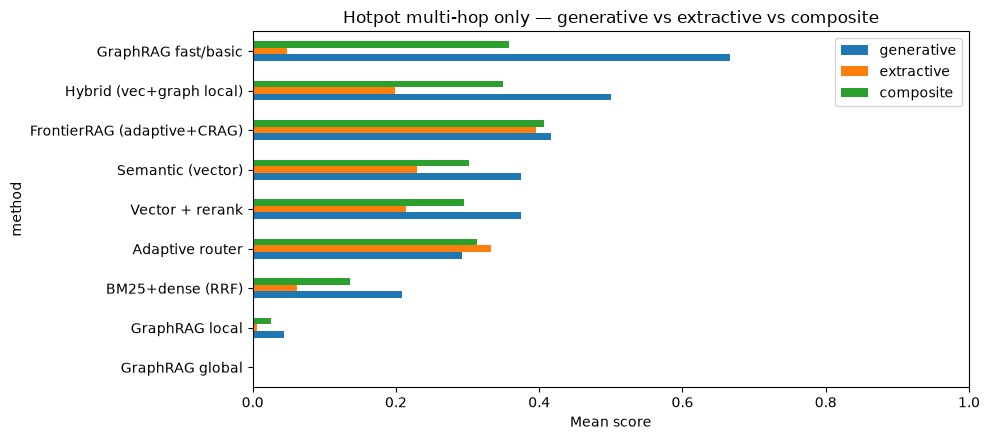

Notice **GraphRAG fast/basic** leads generative multi-hop; extractive/composite tell a different story.

In [4]:
profile = method_metric_profile(acc)
plot_df = profile.set_index("label")[["llm_judge", "contains", "token_f1", "exact_match"]].sort_values("llm_judge")
display(profile[["label", "llm_judge", "contains", "token_f1", "exact_match", "generative", "extractive", "composite"]].round(3))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="barh", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Mean score (0–1)")
ax.set_title("Hotpot n=12 — LLM judge vs lexical metrics by method")
plt.tight_layout()
plt.show()

# Generative vs extractive on multi-hop only
mh = acc[acc.query_type == "hybrid"].groupby("method").agg(
    generative=("generative_score", "mean"),
    extractive=("extractive_score", "mean"),
    composite=("composite_score", "mean"),
).rename(index=lambda m: METHOD_LABELS.get(m, m)).sort_values("generative")
fig2, ax2 = plt.subplots(figsize=(10, 4.5))
mh.plot(kind="barh", ax=ax2)
ax2.set_xlim(0, 1)
ax2.set_title("Hotpot multi-hop only — generative vs extractive vs composite")
ax2.set_xlabel("Mean score")
plt.tight_layout()
plt.show()
display(Markdown("Notice **GraphRAG fast/basic** leads generative multi-hop; extractive/composite tell a different story."))


## Per-question: judge vs EM gap


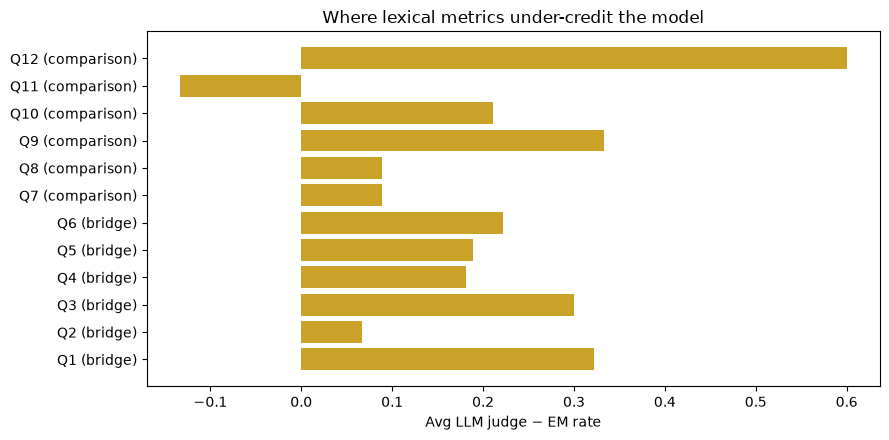

In [5]:
cat = catalog.dropna(subset=["avg_judge", "em_rate"]).copy()
cat["judge_minus_em"] = cat["avg_judge"] - cat["em_rate"]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(cat["label"] + " (" + cat["type"] + ")", cat["judge_minus_em"], color="#c9a227")
ax.set_xlabel("Avg LLM judge − EM rate")
ax.set_title("Where lexical metrics under-credit the model")
plt.tight_layout()
plt.show()


## Concrete failure modes on this set

- **Q1 / Q6 (bridge):** EM=0 across methods. Gold spans (“Chief of Protocol”, “3,677 seated”) rarely appear verbatim.
- **Q12:** Gold includes honorific `DSC`. Predictions omit it → EM=0 while contains≈89% and judge≈0.60.
- **Q3:** Long gold (“Greenwich Village, New York City”) — partial location gets F1/contains, never EM.
- **GraphRAG fast/basic:** judge 0.57, contains 0.67, EM 0.00, F1 0.08 — useful to a human/judge, empty to Hotpot EM.
- **Q11:** Short “yes” — EM and F1 finally agree with judge; vector/rerank shine.

### How to read the scorecard

Prefer **contains + judge (generative)** for generative GraphRAG UX; prefer **EM + F1 (extractive)** for Hotpot-style short answers. Do not conclude “graphs lose multi-hop” from composite alone.
